#EXPERIMENT 2: HOUSING PRICE PREDICTION USING REGRESSION

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Problem Statement

#Develop a regression model to predict house prices using features such as:

#Location

#Area (sqft)

#Bedrooms

#Bathrooms

#Amenities (Parking, Balcony, Furnished)

#Age of the house

#Since house price is a continuous numeric value, this is a Regression problem.

#Problem Definition
↓
#Data Understanding
↓
#Preprocessing (Encoding)
↓
#Train–Test Split
↓
#Regression Model
↓
#Training
↓
#Prediction
↓
#Evaluation (MSE, R²)


#Step 1: Data Understanding

#Each row represents one house

#Target Variable (y):

#Price

#Input Features (X):

#Numerical: Area_sqft, Bedrooms, Bathrooms, Age_Years, Parking, Balcony

#Categorical: Location, Furnished

In [11]:
df = pd.read_csv("/content/drive/MyDrive/AML_Lab/EXP2/Housing_Price_Dataset_120_Records.csv")
df.head()


,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Furnished,Price
0,H001,Rural,1028,1,3,0,0,5,Yes,55.84
1,H002,Rural,2316,1,4,0,0,3,Yes,103.88
2,H003,Urban,1834,1,2,2,2,23,No,86.42
3,H004,Urban,1719,3,1,0,2,14,No,96.77
4,H005,Suburban,1118,2,3,0,0,13,Yes,63.94


#Step 2: Data Preprocessing (Encoding)
- Why Encoding?

#Machine learning models work with numbers, not text.
#So categorical variables must be converted into numeric form.

- One-Hot Encoding:

#Location → Urban / Suburban / Rural

#Furnished → Yes / No

In [12]:
df_encoded = pd.get_dummies(df, columns=['Location', 'Furnished'], drop_first=True)

df_encoded.head()

,HouseID,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Price,Location_Suburban,Location_Urban,Furnished_Yes
0,H001,1028,1,3,0,0,5,55.84,False,False,True
1,H002,2316,1,4,0,0,3,103.88,False,False,True
2,H003,1834,1,2,2,2,23,86.42,False,True,False
3,H004,1719,3,1,0,2,14,96.77,False,True,False
4,H005,1118,2,3,0,0,13,63.94,True,False,True


#Step 3: Feature–Target Split

#We separate:

#X → Input features

#y → Target variable (Price)

In [25]:
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']
X = X.drop(columns=['HouseID'])

#Step 4: Train–Test Split

#Training set → 80%

#Testing set → 20%

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Step 5: Choose Regression Model

#We use Linear Regression because:

#It models the relationship between features and price

#Simple and interpretable

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


#Step 6: Train the Model

#The model learns coefficients by minimizing Mean Squared Error (MSE).

In [28]:
model.fit(X_train, y_train)


LinearRegression()

#Step 7: Make Predictions

In [31]:
y_pred = model.predict(X_test)


#Step 8: Model Evaluation
- Metrics Used:

#Mean Squared Error (MSE)

#R² Score

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 4.116591747805328e-26
R² Score: 1.0


#Step 9: Graphical Evaluation of the Regression Model

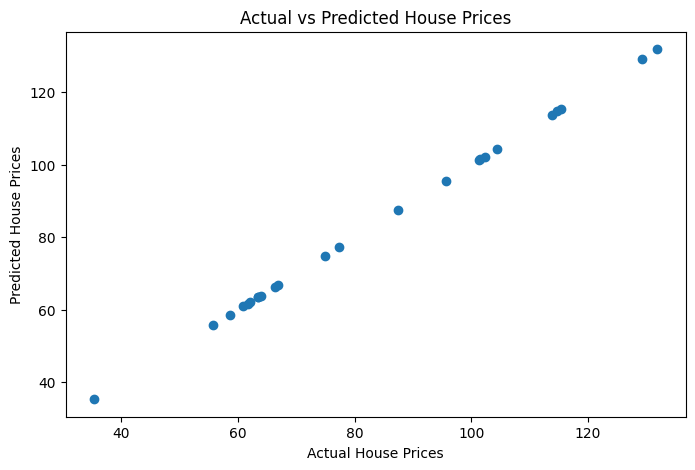

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()
